# Lab 3: Decision Tree Classification : Telco Customer Churn

**Name:** Yusra Batool

**Student ID:** 023-24-0216

**Section:** G

**GitHub Profile:** github.com/Yusra-Shah

**Kaggle Profile:** https://www.kaggle.com/yusrabatool

**Dataset:** Telco Customer Churn

**Dataset Source:** Kaggle

## Part 1 : Problem Definition & Dataset Verification

In [26]:
# Task 1 — load and verify clean_churn.csv
import pandas as pd
import numpy as np

clean_df = pd.read_csv("clean_churn.csv")
print(clean_df.shape)
print(clean_df.dtypes)
print(clean_df.isnull().sum().sum())

(7043, 20)
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object
0


**Problem statement:** We are predicting whether a customer will churn (leave the company), using their account, billing, and service details. This matters because catching likely churners early lets the business offer retention deals before losing that revenue.

## Part 2 : Feature & Target Preparation

In [27]:
# Task 3 — define y and X
y = clean_df["Churn"].map({"No": 0, "Yes": 1})
X = clean_df.drop(columns=["Churn"])

In [28]:
# Task 4 — encode categorical columns
categorical_cols = X.select_dtypes(include=["object", "str"]).columns.tolist()
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(X.shape)

(7043, 30)


**Encoding justification:** One-hot encoding was used instead of manual mapping because most categorical columns (Contract, InternetService, PaymentMethod, etc.) have no natural order between their categories. drop_first=True avoids redundant columns since one category can always be inferred from the rest being 0.

In [29]:
# Task 5 — confirm X is fully numeric with no missing values
print(X.isnull().sum().sum())
print(X.dtypes.value_counts())

0
bool       26
int64       2
float64     2
Name: count, dtype: int64


## Part 3 : Train/Test Split

In [30]:
# Task 6 — train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Why stratify=y:** Lab 2 found the target is imbalanced (about 73% No, 27% Yes). Without stratify, a random split could end up with very different churn rates in train vs test by chance. stratify=y forces both sets to keep the same 73/27 ratio, so the model is trained and tested on a fair, representative split.

In [31]:
# Task 7 — report shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 30)
X_test: (1409, 30)
y_train: (5634,)
y_test: (1409,)


## Part 4 : Baseline Decision Tree

In [32]:
# Task 8 — train baseline Decision Tree
from sklearn.tree import DecisionTreeClassifier

baseline = DecisionTreeClassifier(random_state=42)
baseline.fit(X_train, y_train)
train_preds_baseline = baseline.predict(X_train)
test_preds_baseline = baseline.predict(X_test)

print("Depth:", baseline.get_depth())
print("Leaves:", baseline.get_n_leaves())

Depth: 23
Leaves: 1102


**Tree depth and reaction:** The unrestricted tree grew to depth 23 with 1102 leaves. This is surprising, it's far deeper than needed to separate two classes, meaning it's likely memorizing individual training rows rather than learning general patterns. This is a strong early sign of overfitting.

## Part 5 : Model Evaluation

In [33]:
# Task 10 — accuracy, precision, recall, F1
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

acc = accuracy_score(y_test, test_preds_baseline)
prec = precision_score(y_test, test_preds_baseline)
rec = recall_score(y_test, test_preds_baseline)
f1 = f1_score(y_test, test_preds_baseline)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.7260
Precision: 0.4838
Recall:    0.4786
F1-score:  0.4812


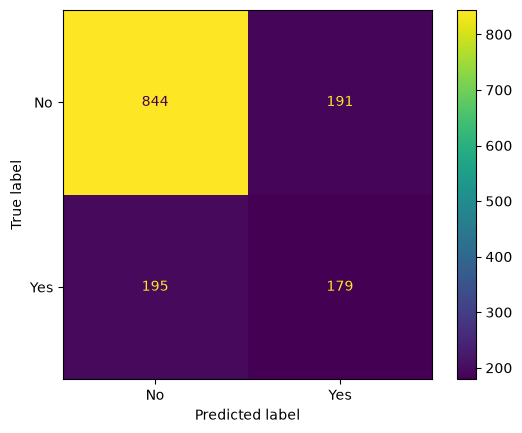

In [34]:
# Task 11 — confusion matrix
cm = confusion_matrix(y_test, test_preds_baseline)
ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"]).plot()

**Confusion matrix interpretation:** Out of 374 actual churners in the test set, the baseline model correctly caught 179 and missed 195, missing more than half. It also wrongly flagged 191 non-churners as churners.

**Which metric(s) to trust and why:** Given the class imbalance from Lab 2, accuracy alone is misleading, a model could score 73% just by predicting "No" every time. Recall matters most here, since the business cares about catching actual churners, and this baseline's recall (0.48) shows it's currently missing more than half of them. F1-score is also useful since it balances precision and recall in one number.

## Part 6 : Overfitting Investigation

In [35]:
# Task 13 — baseline train vs test accuracy
train_acc_baseline = accuracy_score(y_train, train_preds_baseline)
test_acc_baseline = accuracy_score(y_test, test_preds_baseline)
print(f"Train accuracy: {train_acc_baseline:.4f}")
print(f"Test accuracy:  {test_acc_baseline:.4f}")

Train accuracy: 0.9980
Test accuracy:  0.7260


**Gap interpretation:** There's a huge gap, about 27 points, between train accuracy (99.8%) and test accuracy (72.6%). This is a textbook overfitting signature, the model has essentially memorized the training data instead of learning patterns that generalize to new customers.

In [36]:
# Task 14 — multi-depth experiment
depths = [2, 3, 4, 5, 6, 8, 10, None]
results = []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, m.predict(X_train))
    te_acc = accuracy_score(y_test, m.predict(X_test))
    results.append({"max_depth": d if d is not None else "None", "train_acc": round(tr_acc, 4), "test_acc": round(te_acc, 4)})

results_df = pd.DataFrame(results)
print(results_df)

  max_depth  train_acc  test_acc
0         2     0.7911    0.7871
1         3     0.7911    0.7871
2         4     0.7925    0.7956
3         5     0.8023    0.7942
4         6     0.8106    0.8006
5         8     0.8358    0.7828
6        10     0.8727    0.7551
7      None     0.9980    0.7260


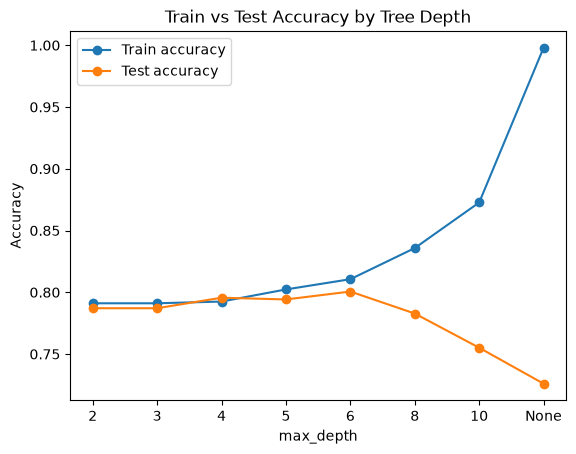

In [37]:
# Task 15 — plot train vs test accuracy against max_depth
import matplotlib.pyplot as plt

depth_labels = [str(d) for d in results_df["max_depth"]]
plt.plot(depth_labels, results_df["train_acc"], marker="o", label="Train accuracy")
plt.plot(depth_labels, results_df["test_acc"], marker="o", label="Test accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy by Tree Depth")
plt.legend()
plt.show()

**Where overfitting starts and why:** Test accuracy peaks at depth 6 (0.8006), then starts declining while train accuracy keeps climbing. From depth 8 onward, train accuracy keeps rising toward 99.8% but test accuracy drops to 0.7551 by depth 10, so the two lines visibly diverge. That growing gap between the two curves is the chart showing overfitting starting around depth 6-8.

## Part 7 : Model Selection, Feature Importance & Interpretation

**Chosen max_depth and justification:** I chose max_depth=6. It has the highest test accuracy (0.8006) of any depth tried, and its train accuracy (0.8106) is close to its test accuracy, a small gap of about 1 point, meaning it generalizes well instead of memorizing. Depths beyond 6 keep improving training accuracy but test accuracy gets worse, which is the overfitting signal from Part 6.

In [38]:
# Task 17 — retrain at chosen depth, full evaluation metrics
best_model = DecisionTreeClassifier(max_depth=6, random_state=42)
best_model.fit(X_train, y_train)
preds_best = best_model.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, preds_best):.4f}")
print(f"Precision: {precision_score(y_test, preds_best):.4f}")
print(f"Recall:    {recall_score(y_test, preds_best):.4f}")
print(f"F1-score:  {f1_score(y_test, preds_best):.4f}")
print(confusion_matrix(y_test, preds_best))

Accuracy:  0.8006
Precision: 0.6667
Recall:    0.4973
F1-score:  0.5697
[[942  93]
 [188 186]]


In [39]:
# Task 18 — retrain with entropy criterion, full evaluation metrics
entropy_model = DecisionTreeClassifier(max_depth=6, criterion="entropy", random_state=42)
entropy_model.fit(X_train, y_train)
preds_entropy = entropy_model.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, preds_entropy):.4f}")
print(f"Precision: {precision_score(y_test, preds_entropy):.4f}")
print(f"Recall:    {recall_score(y_test, preds_entropy):.4f}")
print(f"F1-score:  {f1_score(y_test, preds_entropy):.4f}")
print(confusion_matrix(y_test, preds_entropy))

Accuracy:  0.7942
Precision: 0.6193
Recall:    0.5829
F1-score:  0.6006
[[901 134]
 [156 218]]


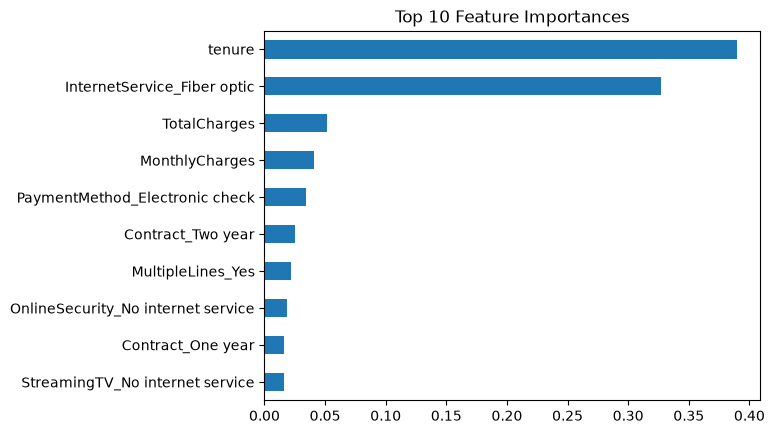

tenure                            0.389640
InternetService_Fiber optic       0.327372
TotalCharges                      0.051916
MonthlyCharges                    0.040819
PaymentMethod_Electronic check    0.034488
dtype: float64


In [40]:
# Task 19 — feature importances
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10).plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.show()
print(importances.head(5))

**Top features and connection to Lab 2 EDA:** tenure and Fiber optic internet service dominate the model's decisions, together making up over 70% of total importance. This directly matches Lab 2's findings, tenure showed the clearest churn split in the boxplot, and fiber optic customers had by far the highest churn rate (42%) of any internet service type. TotalCharges and MonthlyCharges also showing up lines up with the pricing pattern found earlier, higher-paying customers churn more.

## Part 8 : Conclusion & Next Steps

**Conclusion:** I landed on a Decision Tree with max_depth=6, which reached 80% test accuracy with a manageable train-test gap, unlike the unrestricted baseline which overfit badly (99.8% train vs 72.6% test). Its main weakness is recall, it still misses about half of actual churners, since the recall is only about 0.50-0.58 depending on the splitting criterion. The entropy version traded a bit of accuracy for meaningfully better recall, which may matter more for the business than raw accuracy. Overall the model works but isn't strong enough alone to drive real retention decisions without further tuning.

**Next steps:** With more time I'd address the class imbalance directly using class_weight="balanced" or resampling, since the model is currently biased toward the majority "No" class. I'd also try a Random Forest or Gradient Boosting model to see if ensemble methods handle this pattern better than a single tree.

In [41]:
# Task 23 — ID3 from scratch on Play Badminton dataset
import math
from collections import Counter

data = [
    {"Outlook": "Sunny", "Temp": "Hot", "Humidity": "High", "Wind": "Weak", "Play": "No"},
    {"Outlook": "Sunny", "Temp": "Hot", "Humidity": "High", "Wind": "Strong", "Play": "No"},
    {"Outlook": "Overcast", "Temp": "Hot", "Humidity": "High", "Wind": "Weak", "Play": "Yes"},
    {"Outlook": "Rain", "Temp": "Mild", "Humidity": "High", "Wind": "Weak", "Play": "Yes"},
    {"Outlook": "Rain", "Temp": "Cool", "Humidity": "Normal", "Wind": "Weak", "Play": "Yes"},
    {"Outlook": "Rain", "Temp": "Cool", "Humidity": "Normal", "Wind": "Strong", "Play": "No"},
    {"Outlook": "Overcast", "Temp": "Cool", "Humidity": "Normal", "Wind": "Strong", "Play": "Yes"},
    {"Outlook": "Sunny", "Temp": "Mild", "Humidity": "High", "Wind": "Weak", "Play": "No"},
    {"Outlook": "Sunny", "Temp": "Cool", "Humidity": "Normal", "Wind": "Weak", "Play": "Yes"},
    {"Outlook": "Rain", "Temp": "Mild", "Humidity": "Normal", "Wind": "Weak", "Play": "Yes"},
    {"Outlook": "Sunny", "Temp": "Mild", "Humidity": "Normal", "Wind": "Strong", "Play": "Yes"},
    {"Outlook": "Overcast", "Temp": "Mild", "Humidity": "High", "Wind": "Strong", "Play": "Yes"},
    {"Outlook": "Overcast", "Temp": "Hot", "Humidity": "Normal", "Wind": "Weak", "Play": "Yes"},
    {"Outlook": "Rain", "Temp": "Mild", "Humidity": "High", "Wind": "Strong", "Play": "No"},
]

def entropy(rows):
    labels = [r["Play"] for r in rows]
    counts = Counter(labels)
    total = len(rows)
    return -sum((c / total) * math.log2(c / total) for c in counts.values())

def info_gain(rows, attribute):
    total_entropy = entropy(rows)
    values = set(r[attribute] for r in rows)
    weighted_entropy = 0
    for v in values:
        subset = [r for r in rows if r[attribute] == v]
        weighted_entropy += (len(subset) / len(rows)) * entropy(subset)
    return total_entropy - weighted_entropy

def id3(rows, attributes, depth=0):
    labels = [r["Play"] for r in rows]
    if len(set(labels)) == 1:
        print("  " * depth + f"Leaf: {labels[0]}")
        return
    if not attributes:
        majority = Counter(labels).most_common(1)[0][0]
        print("  " * depth + f"Leaf (majority): {majority}")
        return

    gains = {attr: info_gain(rows, attr) for attr in attributes}
    print("  " * depth + f"Gains at this split: {gains}")
    best_attr = max(gains, key=gains.get)
    print("  " * depth + f"Best split: {best_attr} (gain={gains[best_attr]:.4f})")

    remaining_attrs = [a for a in attributes if a != best_attr]
    for v in set(r[best_attr] for r in rows):
        subset = [r for r in rows if r[best_attr] == v]
        print("  " * depth + f"-> {best_attr} = {v}")
        id3(subset, remaining_attrs, depth + 1)

attributes = ["Outlook", "Temp", "Humidity", "Wind"]
id3(data, attributes)

Gains at this split: {'Outlook': 0.24674981977443933, 'Temp': 0.02922256565895487, 'Humidity': 0.15183550136234159, 'Wind': 0.04812703040826949}
Best split: Outlook (gain=0.2467)
-> Outlook = Overcast
  Leaf: Yes
-> Outlook = Rain
  Gains at this split: {'Temp': 0.01997309402197489, 'Humidity': 0.01997309402197489, 'Wind': 0.9709505944546686}
  Best split: Wind (gain=0.9710)
  -> Wind = Strong
    Leaf: No
  -> Wind = Weak
    Leaf: Yes
-> Outlook = Sunny
  Gains at this split: {'Temp': 0.5709505944546686, 'Humidity': 0.9709505944546686, 'Wind': 0.01997309402197489}
  Best split: Humidity (gain=0.9710)
  -> Humidity = Normal
    Leaf: Yes
  -> Humidity = High
    Leaf: No


## Submission Checklist
- [x] Problem Definition
- [x] Dataset Verification
- [x] Feature/Target Preparation
- [x] Train/Test Split
- [x] Baseline Decision Tree
- [x] Model Evaluation
- [x] Overfitting Experiment
- [x] Model Comparison
- [x] Feature Importance
- [x] Interpretation
- [x] Conclusion